In [24]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [25]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_wine 
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score 


wine = load_wine() 
x = wine.data 
feature_names = wine.feature_names 
df = pd.DataFrame(x, columns=feature_names)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (178, 13)

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_dilu

In [26]:
selected_features = ['alcohol', 'malic_acid']
x_selected = df[selected_features].values 

print("\nselected features:", selected_features)


selected features: ['alcohol', 'malic_acid']


In [27]:
scaler = StandardScaler() 
x_scaled = scaler.fit_transform(x_selected)
print("feature scaling completed")


feature scaling completed


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

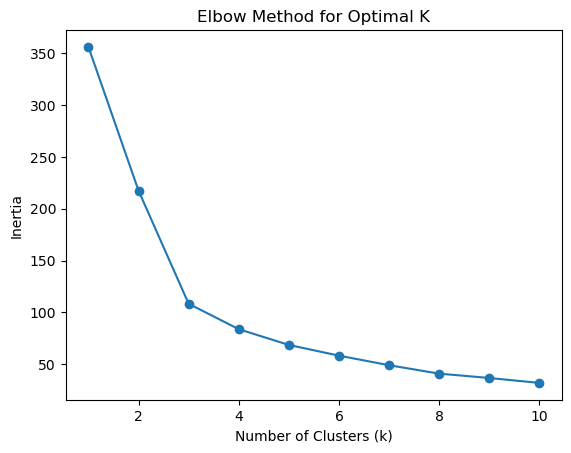

In [31]:
inertia_values = [] 
k_range = range(1,11)

for k in k_range: 
    kmeans = KMeans(n_clusters=k , random_state=42 , n_init=10 )
    kmeans.fit(x_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure() 
plt.plot(k_range, inertia_values, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [18]:
kmeans = KMeans(n_clusters=3 , random_state=42 , n_init=10)
clusters = kmeans.fit_predict(x_scaled)
df['Cluster'] = clusters 
print("\n clusters centers (scaled values): ")
print(kmeans.cluster_centers_)


 clusters centers (scaled values): 
[[-0.98858319 -0.5829103 ]
 [ 0.09906621  1.41480748]
 [ 0.87009843 -0.493973  ]]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


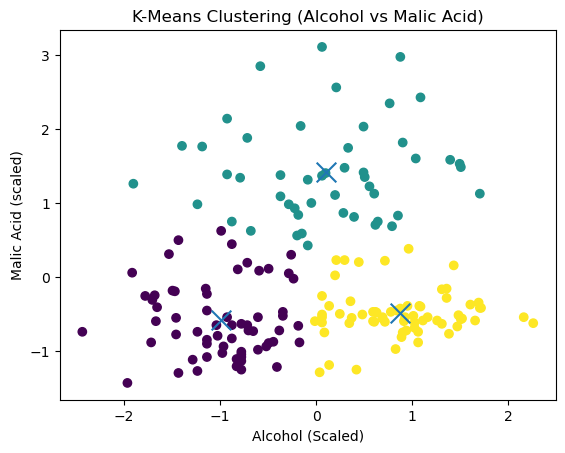

In [19]:
plt.figure() 
plt.scatter(
    x_scaled[:,0],
    x_scaled[:,1], 
    c=clusters
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1], 
    marker='x', 
    s=200
          
)
plt.title("K-Means Clustering (Alcohol vs Malic Acid)")
plt.xlabel("Alcohol (Scaled)")
plt.ylabel("Malic Acid (scaled)")
plt.show()
    

In [20]:
sil_score = silhouette_score(x_scaled, clusters)
print("\nsilhosilhouette_score:  ", sil_score)


silhosilhouette_score:   0.484095893654603


In [22]:
print ("\nnumber of slamples in each clusters: ")
print (df['Cluster'].value_counts())


number of slamples in each clusters: 
Cluster
2    66
0    63
1    49
Name: count, dtype: int64
